# Uncertain Volatility Backbone — Percentile-Pinned 6p with Tightened β Bounds

## Motivation

The previous notebook (`Uncertain Vol - Percentile Pinned 6p.ipynb`) pinned
`sigma_ln` to the p5/p50/p95 of each regime's ATM IV, reducing the fit from 9
to 6 parameters.  While the σ-collapse was eliminated, the optimiser simply
relocated the collapse: **weights went one-hot** on the lowest-σ state and
**β hit the 0.10 lower bound** in most states.

With β = 0.10, the displacement shift inside the pricer,
`S_ref · (1-β)/β = 9 · S_ref`, is enormous (~20k–40k), producing OTM smiles
that **overestimate** observed OTM put IV by 50–90%.

## This experiment

We repeat the 6p percentile-pinned fit but **tighten the β bounds** from
`(0.1, 0.95)` to **`(0.5, 0.95)`**.  This caps the displacement leverage at
`S_ref · (1-β)/β ≤ 1.0 · S_ref`, preventing the extreme smile amplification
seen in the original 6p fit.

Three-way comparison throughout:

  * **9p** — original 9-parameter fit (loaded from `fits_regime_mse.pkl`)
  * **6p** — original 6p fit with β ∈ [0.1, 0.95] (loaded from `fits_regime_mse_6p.pkl`)
  * **6p-tight** — new 6p fit with β ∈ [0.5, 0.95] (this notebook)


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import pickle

import option_pricers as op
import importlib
importlib.reload(op)

TARGET_TAU = 30 / 365
R = 0.02

def regime(year):
    if year <= 2017:
        return 'Low Vol (2015-17)'
    elif year <= 2019:
        return 'Transition (2018-19)'
    elif year == 2020:
        return 'COVID'
    else:
        return 'Post-COVID'

REGIMES = ['Low Vol (2015-17)', 'Transition (2018-19)', 'COVID', 'Post-COVID']

regime_colors = {
    'Low Vol (2015-17)':    '#ff7f0e',
    'Transition (2018-19)': '#d62728',
    'COVID':                '#1f77b4',
    'Post-COVID':           '#2ca02c',
}

# -----------------------------------------------------------------------------
# Vectorised uncertain-backbone (same as the 6p notebook)
# -----------------------------------------------------------------------------
def _implied_vol_newton(S, K, r, price, T, sigma_init=0.2, tol=1e-9, max_it=80):
    S     = np.broadcast_arrays(np.asarray(S, float), np.asarray(K, float),
                               np.asarray(price, float))[0]
    K     = np.broadcast_arrays(np.asarray(K, float), S)[0]
    price = np.broadcast_arrays(np.asarray(price, float), S)[0]
    sigma = np.full_like(S, sigma_init, dtype=float)
    for _ in range(max_it):
        sqrtT = np.sqrt(T)
        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*sqrtT)
        d2 = d1 - sigma*sqrtT
        model = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        vega  = S*norm.pdf(d1)*sqrtT
        vega_safe = np.where(vega > 1e-12, vega, 1e-12)
        sigma_new = np.clip(sigma - (model - price) / vega_safe, 1e-6, 10.0)
        if np.max(np.abs(sigma_new - sigma)) < tol:
            sigma = sigma_new; break
        sigma = sigma_new
    final_d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    final_d2 = final_d1 - sigma*np.sqrt(T)
    final_model = S*norm.cdf(final_d1) - K*np.exp(-r*T)*norm.cdf(final_d2)
    bad = np.abs(final_model - price) > 1e-6 * np.maximum(price, 1e-12)
    return np.where(bad, np.nan, sigma)

def uncertain_backbone_fast(S_arr, K_arr, r, T, weights, betas, sigmas_n, sigmas_ln):
    S = np.asarray(S_arr, dtype=float); K = np.asarray(K_arr, dtype=float)
    weights  = np.asarray(weights,  dtype=float)
    betas   = np.asarray(betas,    dtype=float)
    sigmas_n  = np.asarray(sigmas_n, dtype=float)
    sigmas_ln = np.asarray(sigmas_ln, dtype=float)
    base_shape = np.broadcast_shapes(S.shape, K.shape)
    S_b = np.broadcast_to(S, base_shape); K_b = np.broadcast_to(K, base_shape)
    sh = (weights.size,) + base_shape
    S_st = np.broadcast_to(S_b, sh); K_st = np.broadcast_to(K_b, sh)
    shift = sigmas_n * (1 - betas) / (sigmas_ln * betas)
    S_ = S_st + shift[(slice(None),) + (None,)*len(base_shape)]
    K_ = K_st + shift[(slice(None),) + (None,)*len(base_shape)]
    sigma_ = np.broadcast_to((sigmas_ln * betas)[(slice(None),) + (None,)*len(base_shape)], sh).astype(float)
    d1 = (np.log(S_/K_) + (r + 0.5*sigma_**2)*T) / (sigma_*np.sqrt(T))
    d2 = d1 - sigma_*np.sqrt(T)
    call_prices = S_*norm.cdf(d1) - K_*np.exp(-r*T)*norm.cdf(d2)
    w_shape = weights.reshape((weights.size,) + (1,)*len(base_shape))
    model_price = (w_shape * call_prices).sum(axis=0)
    return _implied_vol_newton(S_b, K_b, r, model_price, T)


## 2. Load data and existing fits

In [2]:
# ATM data
iv1m_df = pd.read_csv('./processed_data/1M_ATM.csv', parse_dates=['datetime'])
iv1m_df['year'] = iv1m_df['datetime'].dt.year
if 'regime' not in iv1m_df.columns:
    iv1m_df['regime'] = iv1m_df['year'].apply(regime)

# OTM data
iv1m_k_pc_df = pd.read_csv('./processed_data/iv1m_k_pc.csv', parse_dates=['datetime'])
if 'year' not in iv1m_k_pc_df.columns:
    iv1m_k_pc_df['year'] = iv1m_k_pc_df['datetime'].dt.year
if 'regime' not in iv1m_k_pc_df.columns:
    iv1m_k_pc_df['regime'] = iv1m_k_pc_df['year'].apply(regime)

K_VALS = sorted(iv1m_k_pc_df['k'].unique())   # [-0.2, -0.1, 0.0, 0.1, 0.2]

# 9p fits
with open('./processed_data/fits_regime_mse.pkl', 'rb') as f:
    fits_9p = pickle.load(f)

# 6p (original, β ∈ [0.1, 0.95])
with open('./processed_data/fits_regime_mse_6p.pkl', 'rb') as f:
    fits_6p = pickle.load(f)

# σ_ln pinned per regime (same as 6p notebook)
def pinned_sigmas_ln(atm_iv_series):
    p5, p50, p95 = np.percentile(atm_iv_series, [5, 50, 95])
    return np.array([p5, p50, p95], dtype=float)

sigma_ln_pinned_by_regime = {}
for reg in REGIMES:
    g = iv1m_df[iv1m_df['regime'] == reg]
    sigma_ln_pinned_by_regime[reg] = pinned_sigmas_ln(g['atm_iv_1m'].values)

print(f'ATM data : {len(iv1m_df)} rows')
print(f'OTM data : {len(iv1m_k_pc_df)} rows')
print(f'k levels : {K_VALS}')
print()
print('Pinned sigma_ln per regime:')
for reg in REGIMES:
    sl = sigma_ln_pinned_by_regime[reg]
    print(f'  {reg:24s} p5={sl[0]:.4f}  p50={sl[1]:.4f}  p95={sl[2]:.4f}')
print()
print('Loaded 9p and 6p (original β∈[0.1,0.95]) fits for comparison.')


ATM data : 2405 rows
OTM data : 11599 rows
k levels : [np.float64(-0.2), np.float64(-0.1), np.float64(0.0), np.float64(0.1), np.float64(0.2)]

Pinned sigma_ln per regime:
  Low Vol (2015-17)        p5=0.0797  p50=0.1139  p95=0.1918
  Transition (2018-19)     p5=0.0990  p50=0.1334  p95=0.1958
  COVID                    p5=0.0991  p50=0.1913  p95=0.3764
  Post-COVID               p5=0.1137  p50=0.1615  p95=0.2727

Loaded 9p and 6p (original β∈[0.1,0.95]) fits for comparison.


## 3. 6p-tight loss — β ∈ [0.5, 0.95]

The loss is identical to the original 6p loss; only the **bounds** on β change.


In [3]:
def loss_6p(params, S_data, iv_data, sigma_ln_pinned, r, T):
    """6-parameter MSE loss. sigma_ln fixed via percentile pinning."""
    weights_pre = params[0:3].astype(float)
    betas       = params[3:6].astype(float)
    sigma_ln    = np.asarray(sigma_ln_pinned, dtype=float)
    weights     = np.exp(weights_pre) / np.sum(np.exp(weights_pre))
    S_ref       = float(np.mean(S_data))
    sigmas_n    = sigma_ln * S_ref
    if np.any(betas <= 0) or np.any(sigma_ln <= 0):
        return 1e6
    S_arr = np.asarray(S_data, dtype=float)
    model_ivs = uncertain_backbone_fast(S_arr, S_arr, r, T,
                                        weights, betas, sigmas_n, sigma_ln)
    if np.any(np.isnan(model_ivs)):
        return 1e6
    return float(np.mean((model_ivs - np.asarray(iv_data, dtype=float))**2))


## 4. Multistart L-BFGS-B fit — β ∈ [0.5, 0.95]

In [4]:
N_STARTS = 16
SEED     = 42
MAXITER  = 400

# TIGHT β bounds: (0.5, 0.95) instead of (0.1, 0.95)
BOUNDS_6P_TIGHT = [(None, None)] * 3 + [(0.5, 0.95)] * 3

def make_multistart_inits(rng):
    """16 inits: 3 anchor + 13 random.
       β drawn from U(0.55, 0.90) to respect the tightened bounds."""
    inits = []
    for i in range(3):
        logits = np.array([-1.0, -1.0, -1.0]); logits[i] = 3.0
        betas  = np.array([0.60, 0.75, 0.90])
        inits.append(np.concatenate([logits, betas]))
    while len(inits) < N_STARTS:
        logits = rng.normal(0.0, 0.8, size=3)
        betas  = rng.uniform(0.55, 0.90, size=3)
        inits.append(np.concatenate([logits, betas]))
    return inits

fits_6p_tight = {}
multistart_trace = {}

for reg in REGIMES:
    g = iv1m_df[iv1m_df['regime'] == reg]
    S_data = g['spot'].values.astype(float)
    iv_data = g['atm_iv_1m'].values.astype(float)
    sigma_ln_pinned = sigma_ln_pinned_by_regime[reg]

    rng = np.random.default_rng(SEED)
    inits = make_multistart_inits(rng)

    best = None; funs = []
    for x0 in inits:
        res = minimize(
            loss_6p, x0,
            args=(S_data, iv_data, sigma_ln_pinned, R, TARGET_TAU),
            method='L-BFGS-B',
            bounds=BOUNDS_6P_TIGHT,
            options={'maxiter': MAXITER}
        )
        funs.append(float(res.fun))
        if (best is None) or (res.fun < best.fun):
            best = res

    fit_params = best.x
    w_pre  = fit_params[:3]
    w_post = np.exp(w_pre) / np.sum(np.exp(w_pre))
    beta   = fit_params[3:6]
    S_ref  = float(np.mean(S_data))
    sigmas_n = list(sigma_ln_pinned * S_ref)

    fits_6p_tight[reg] = {
        'params':          fit_params,
        'weights':         w_post,
        'betas':           beta,
        'sigma_ln_pinned': sigma_ln_pinned,
        'sigmas_n':        sigmas_n,
        'S_ref':           S_ref,
        'success':         best.success,
        'fun':             float(best.fun),
        'niter':           best.nit,
    }
    multistart_trace[reg] = funs

    print(f'{reg:24s} 6p-tight MSE = {best.fun:.6f}  '
          f'(6p-orig: {fits_6p[reg]["fun"]:.6f}, 9p: {fits_9p[reg]["fun"]:.6f})  '
          f'conv={best.success} nit={best.nit}')
    print(f'   weights   = {np.round(w_post, 4)}')
    print(f'   betas     = {np.round(beta, 4)}')
    print(f'   sigma_ln  = {np.round(sigma_ln_pinned, 4)} (pinned)')

with open('./processed_data/fits_regime_mse_6p_tight.pkl', 'wb') as f:
    pickle.dump(fits_6p_tight, f)
print('\nSaved 6p-tight fits.')


Low Vol (2015-17)        6p-tight MSE = 0.000932  (6p-orig: 0.000787, 9p: 0.000795)  conv=True nit=5
   weights   = [0.512  0.2654 0.2226]
   betas     = [0.5 0.5 0.5]
   sigma_ln  = [0.0797 0.1139 0.1918] (pinned)


Transition (2018-19)     6p-tight MSE = 0.000978  (6p-orig: 0.000905, 9p: 0.000907)  conv=True nit=6
   weights   = [0.499  0.2472 0.2538]
   betas     = [0.5 0.5 0.5]
   sigma_ln  = [0.099  0.1334 0.1958] (pinned)


COVID                    6p-tight MSE = 0.006272  (6p-orig: 0.005626, 9p: 0.005632)  conv=True nit=6
   weights   = [0.3966 0.3461 0.2572]
   betas     = [0.5 0.5 0.5]
   sigma_ln  = [0.0991 0.1913 0.3764] (pinned)


Post-COVID               6p-tight MSE = 0.002504  (6p-orig: 0.002463, 9p: 0.002463)  conv=True nit=3
   weights   = [0.5094 0.2627 0.2279]
   betas     = [0.5 0.5 0.5]
   sigma_ln  = [0.1137 0.1615 0.2727] (pinned)

Saved 6p-tight fits.


## 5. ATM backbone — three-way comparison

6p-tight (solid black) vs 6p-original (dashed gray) vs 9p (dotted regime-color).


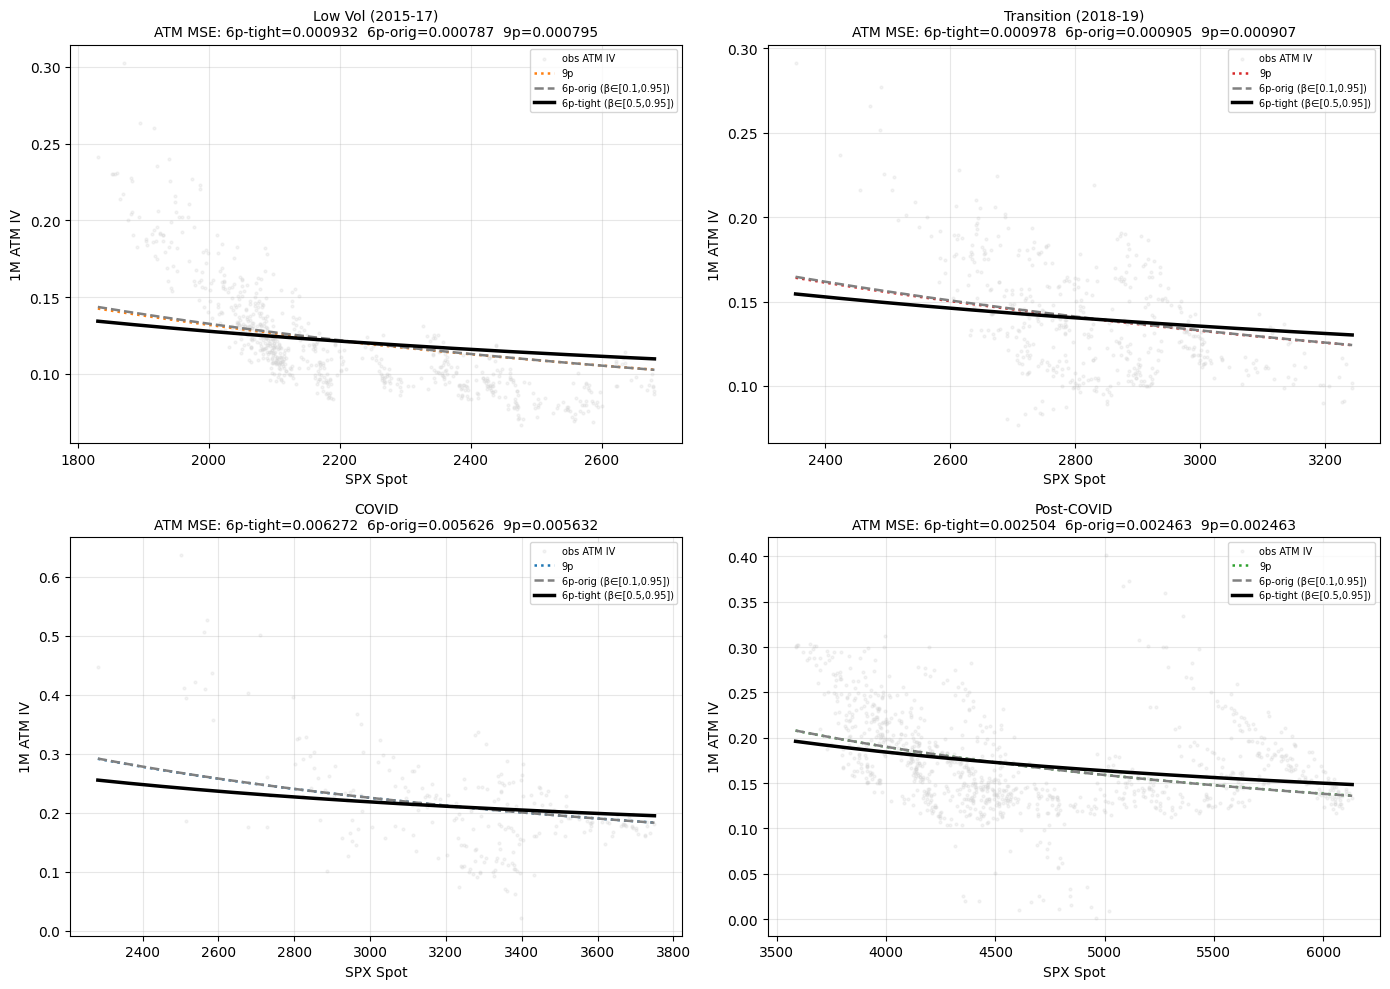

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, reg in zip(axes.flat, REGIMES):
    g = iv1m_df[iv1m_df['regime'] == reg]
    S_grid = np.linspace(g['spot'].min(), g['spot'].max(), 200)

    # 9p
    p9 = fits_9p[reg]['params']
    w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
    m_9p = uncertain_backbone_fast(S_grid, S_grid, R, TARGET_TAU, w9, p9[3:6], np.abs(p9[6:9])*g['spot'].mean(), np.abs(p9[6:9]))

    # 6p original
    f6o = fits_6p[reg]
    m_6po = uncertain_backbone_fast(S_grid, S_grid, R, TARGET_TAU, f6o['weights'], f6o['betas'], np.array(f6o['sigmas_n']), f6o['sigma_ln_pinned'])

    # 6p tight
    f6t = fits_6p_tight[reg]
    m_6pt = uncertain_backbone_fast(S_grid, S_grid, R, TARGET_TAU, f6t['weights'], f6t['betas'], np.array(f6t['sigmas_n']), f6t['sigma_ln_pinned'])

    ax.scatter(g['spot'], g['atm_iv_1m'], s=4, alpha=0.25, color='lightgray', label='obs ATM IV')
    ax.plot(S_grid, m_9p,  color=regime_colors[reg], linewidth=1.8, linestyle=':',  label='9p')
    ax.plot(S_grid, m_6po, color='gray',             linewidth=1.8, linestyle='--', label='6p-orig (β∈[0.1,0.95])')
    ax.plot(S_grid, m_6pt, color='black',            linewidth=2.5,                  label='6p-tight (β∈[0.5,0.95])')
    ax.set_title(f'{reg}\nATM MSE: 6p-tight={f6t["fun"]:.6f}  6p-orig={f6o["fun"]:.6f}  9p={fits_9p[reg]["fun"]:.6f}', fontsize=10)
    ax.set_xlabel('SPX Spot'); ax.set_ylabel('1M ATM IV')
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


## 6. Direct OTM evaluation — 6p-tight

The model is evaluated **directly** at `K = S_repr · exp(k)` for each
`(regime, k)` bucket, with no additive shift.


In [6]:
direct_otm_rows = []

for reg in REGIMES:
    f6t = fits_6p_tight[reg]
    w6, b6, sl6 = f6t['weights'], f6t['betas'], f6t['sigma_ln_pinned']
    S_repr = f6t['S_ref']
    sn6 = sl6 * S_repr

    for k in K_VALS:
        K = S_repr * np.exp(k)
        m_iv = uncertain_backbone_fast(np.array([S_repr]), np.array([K]), R, TARGET_TAU,
                                      w6, b6, sn6, sl6)[0]
        if np.isnan(m_iv):
            continue
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset) == 0:
            continue
        obs_mean = float(subset['iv_1m'].mean())
        direct_otm_rows.append({
            'regime': reg, 'k': k, 'n': len(subset),
            'observed_OTM_mean': round(obs_mean, 4),
            'model_OTM_direct_6p_tight': round(float(m_iv), 4),
            'residual': round(float(m_iv) - obs_mean, 4),
            'rel_residual (%)': round(100 * (float(m_iv) - obs_mean) / obs_mean, 2),
        })

direct_otm_df = pd.DataFrame(direct_otm_rows)
print(direct_otm_df.to_string(index=False))


              regime    k   n  observed_OTM_mean  model_OTM_direct_6p_tight  residual  rel_residual (%)
   Low Vol (2015-17) -0.1 703             0.2214                     0.2339    0.0125              5.64
   Low Vol (2015-17)  0.0 705             0.1210                     0.1214    0.0004              0.36
   Low Vol (2015-17)  0.1 613             0.0943                     0.1510    0.0567             60.16
   Low Vol (2015-17)  0.2 450             0.1189                     0.1693    0.0505             42.46
Transition (2018-19) -0.1 471             0.2303                     0.2355    0.0052              2.26
Transition (2018-19)  0.0 472             0.1395                     0.1397    0.0002              0.16
Transition (2018-19)  0.1 469             0.1293                     0.1570    0.0278             21.50
Transition (2018-19)  0.2 446             0.1787                     0.1736   -0.0051             -2.88
               COVID -0.1 232             0.3653                

## 7. OTM backbone vs spot — 6p-tight direct vs 9p additive-shift

Per-regime, 4 OTM panels (k = -0.2, -0.1, +0.1, +0.2). Each panel shows:
  * **6p-tight direct** OTM backbone (solid black)
  * **9p additive-shift** backbone (dashed regime-color)
  * Observed OTM IV scatter


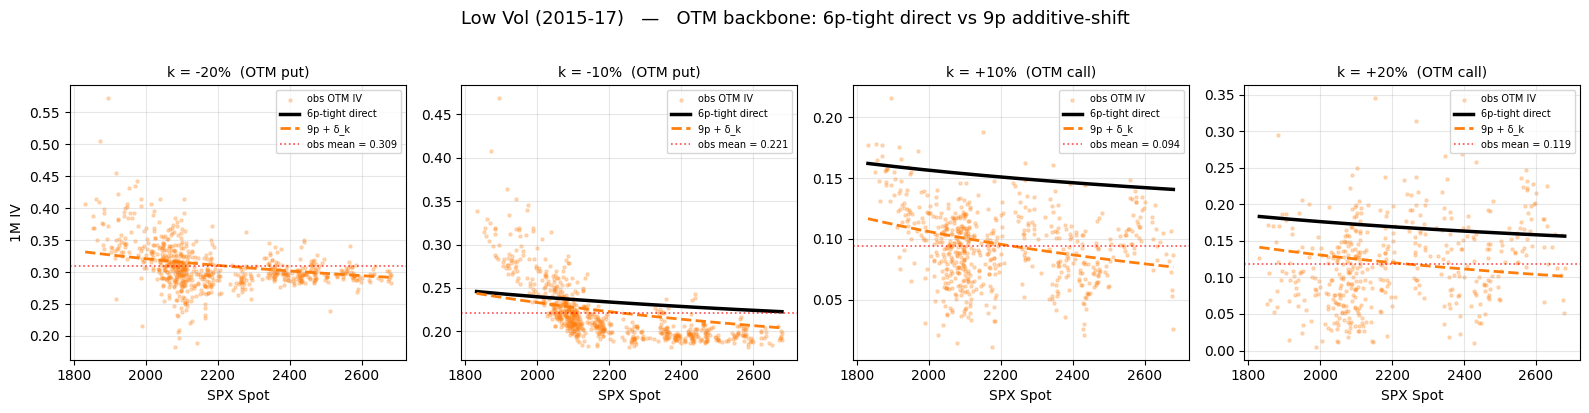

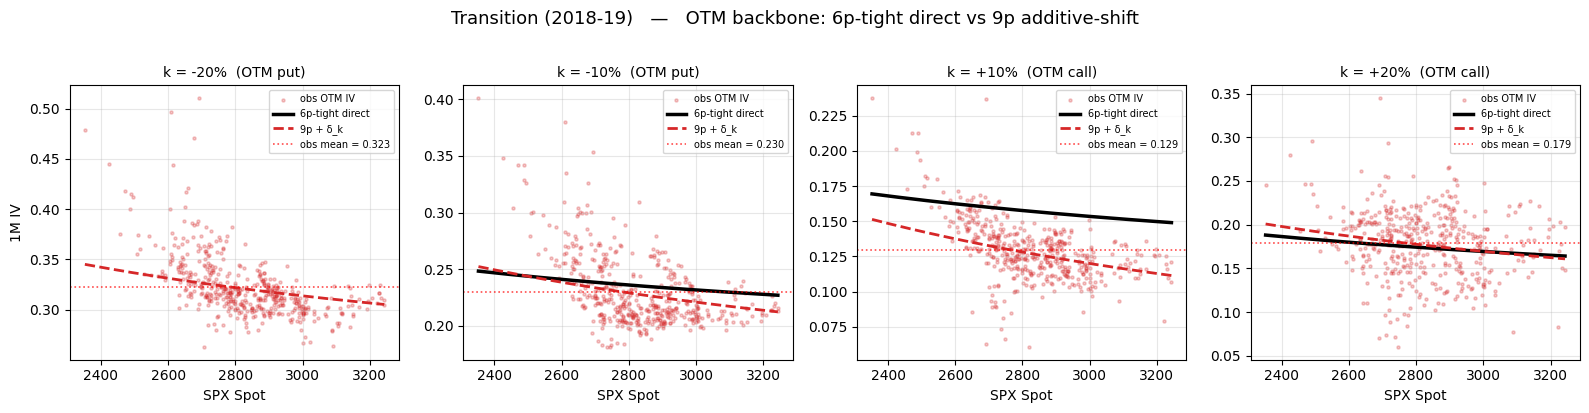

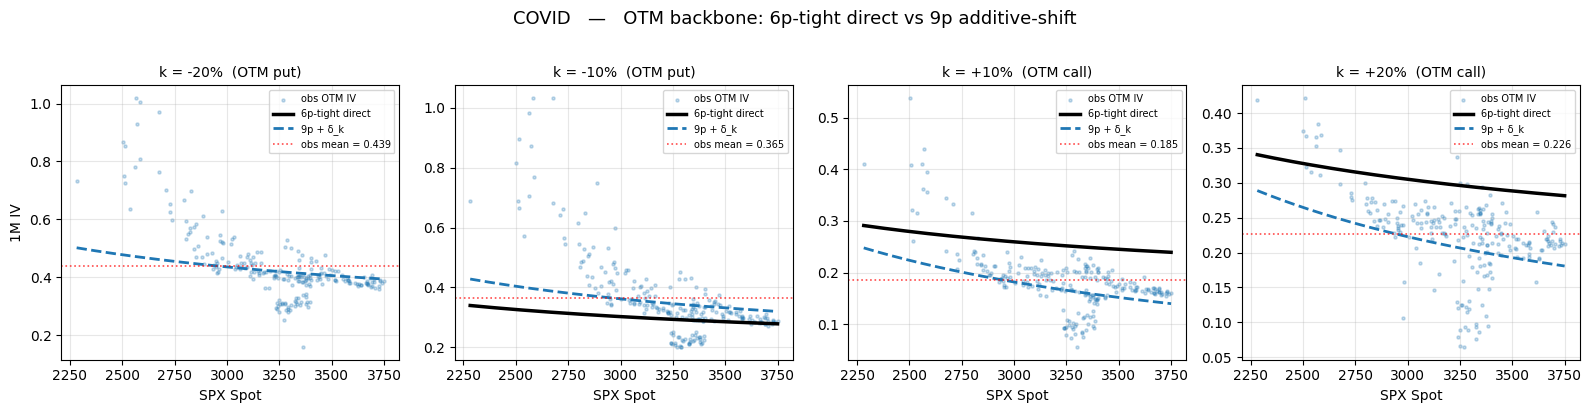

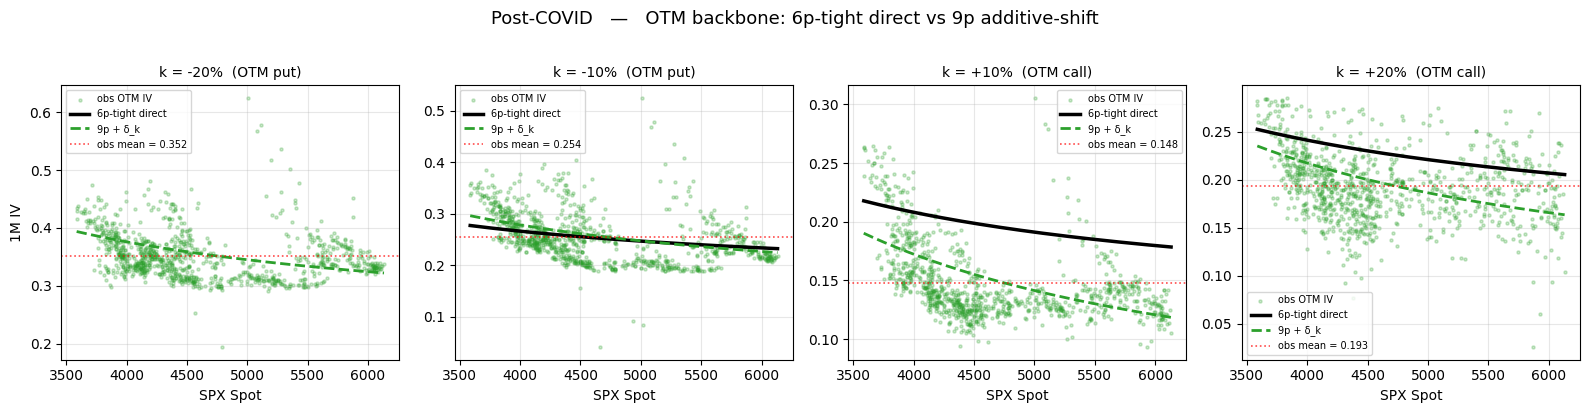

In [7]:
K_PLOT = [k for k in K_VALS if k != 0.0]

for reg in REGIMES:
    g_atm = iv1m_df[iv1m_df['regime'] == reg]
    f6t = fits_6p_tight[reg]
    w6, b6, sl6 = f6t['weights'], f6t['betas'], f6t['sigma_ln_pinned']
    S_ref = f6t['S_ref']
    sn6  = sl6 * S_ref

    p9 = fits_9p[reg]['params']
    w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
    b9 = p9[3:6]; sl9 = np.abs(p9[6:9]); sn9 = sl9 * S_ref

    S_min = g_atm['spot'].min(); S_max = g_atm['spot'].max()
    S_grid = np.linspace(S_min, S_max, 150)
    atm_9p_grid = uncertain_backbone_fast(S_grid, S_grid, R, TARGET_TAU, w9, b9, sn9, sl9)
    atm_9p_mean = float(np.nanmean(atm_9p_grid))

    n_panels = len(K_PLOT)
    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4), sharey=False)
    if n_panels == 1: axes = [axes]

    for ax, k_val in zip(axes, K_PLOT):
        K_grid = S_grid * np.exp(k_val)
        backbone_6pt = uncertain_backbone_fast(S_grid, K_grid, R, TARGET_TAU, w6, b6, sn6, sl6)

        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset):
            otm_obs_mean = float(subset['iv_1m'].mean())
            delta_k = otm_obs_mean - atm_9p_mean
            backbone_9p_shifted = atm_9p_grid + delta_k
        else:
            otm_obs_mean = np.nan; backbone_9p_shifted = np.full_like(S_grid, np.nan)

        ax.scatter(subset['spot'], subset['iv_1m'], s=5, alpha=0.25,
                   color=regime_colors[reg], label='obs OTM IV')
        ax.plot(S_grid, backbone_6pt, color='black', linewidth=2.5,
                label='6p-tight direct')
        ax.plot(S_grid, backbone_9p_shifted, color=regime_colors[reg],
                linewidth=2.0, linestyle='--', label='9p + δ_k')
        if not np.isnan(otm_obs_mean):
            ax.axhline(otm_obs_mean, color='red', linestyle=':', linewidth=1.2,
                       alpha=0.7, label=f'obs mean = {otm_obs_mean:.3f}')

        sign = '-' if k_val < 0 else '+'; pct = int(abs(k_val) * 100)
        put_call = 'put' if k_val < 0 else 'call'
        ax.set_title(f'k = {sign}{pct}%  (OTM {put_call})', fontsize=10)
        ax.set_xlabel('SPX Spot')
        if ax is axes[0]: ax.set_ylabel('1M IV')
        ax.grid(alpha=0.3); ax.legend(fontsize=7)

    fig.suptitle(f'{reg}   —   OTM backbone: 6p-tight direct vs 9p additive-shift',
                 fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


## 8. Cross-regime OTM backbones — all regimes together

For each moneyness bucket `k ∈ {-0.2 put, -0.1 put, +0.1 call, +0.2 put}`,
this figure overlays **all four regimes** on a single spot axis:

  * **Solid line** = 6p-tight direct OTM backbone
  * **Dashed line** = 9p additive-shift backbone
  * Light dots = observed OTM IV scatter, coloured by regime


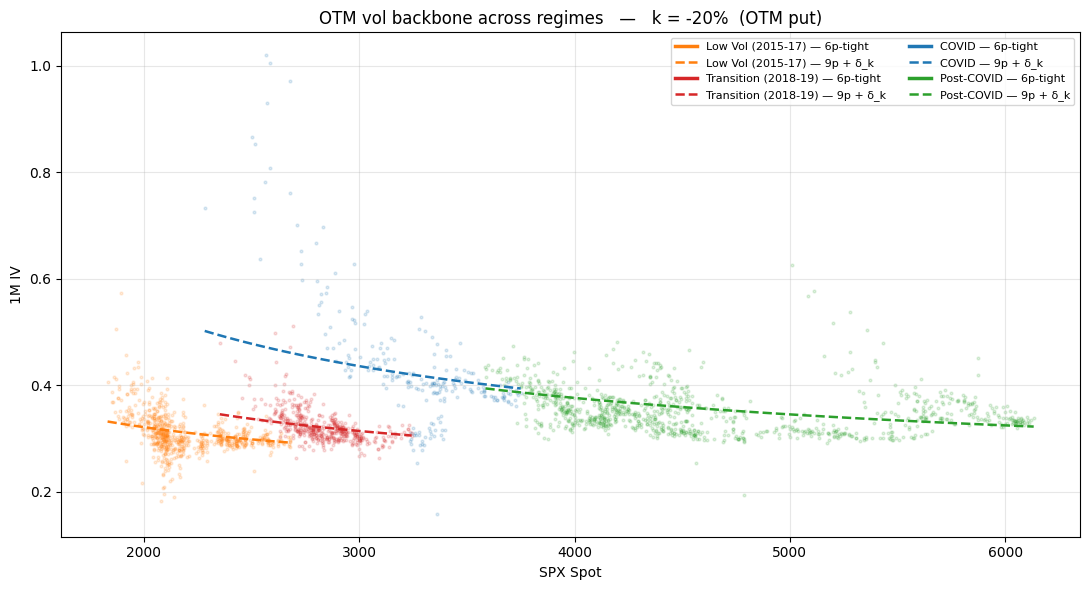

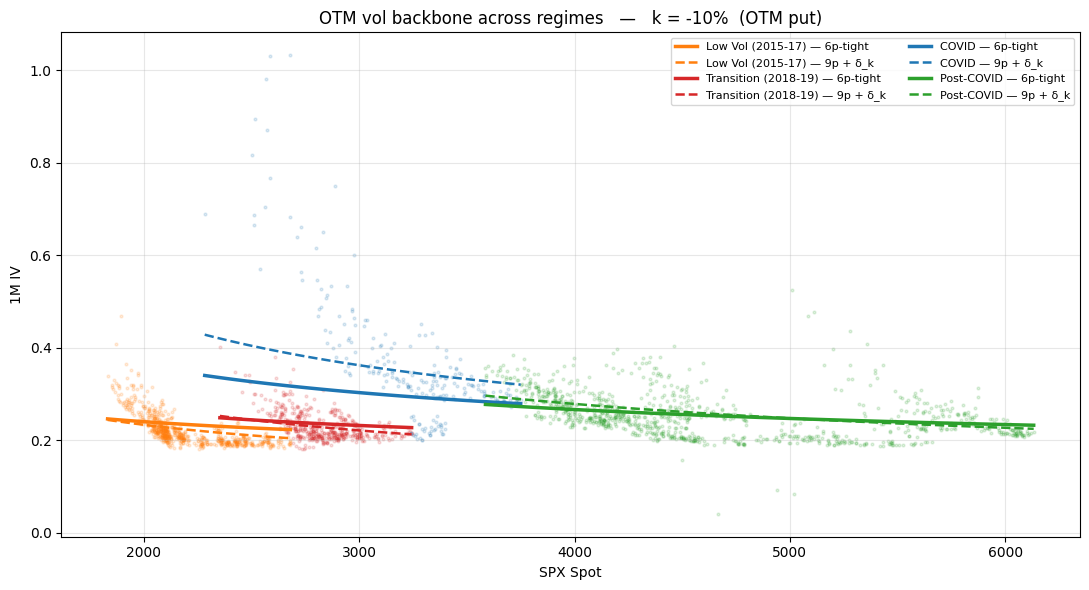

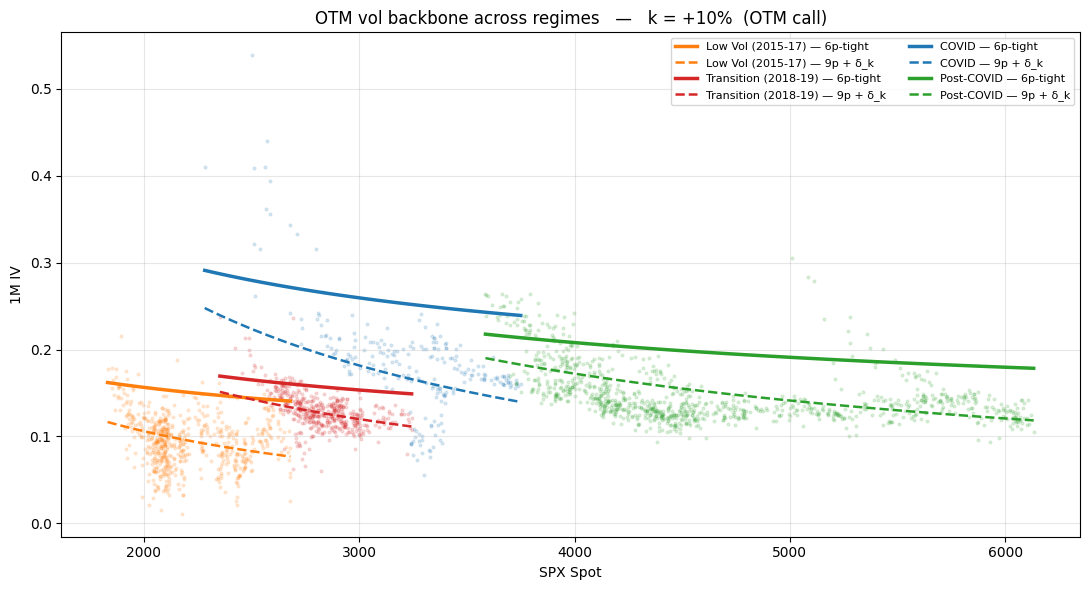

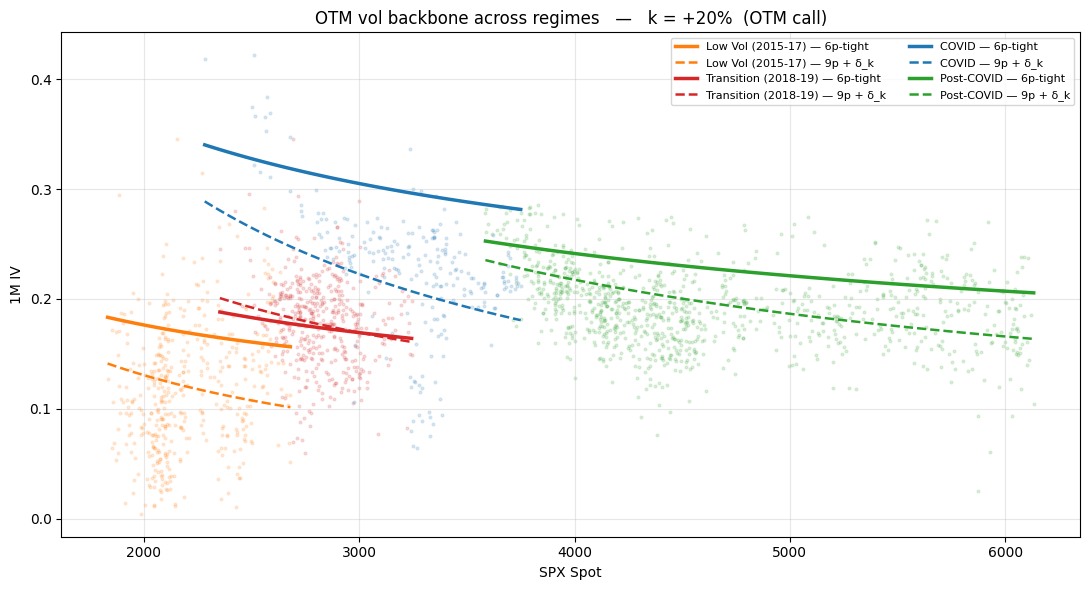

In [8]:
K_PLOT_CROSS = [-0.2, -0.1, 0.1, 0.2]

for k_val in K_PLOT_CROSS:
    fig, ax = plt.subplots(figsize=(11, 6))

    for reg in REGIMES:
        f6t = fits_6p_tight[reg]
        w6, b6, sl6 = f6t['weights'], f6t['betas'], f6t['sigma_ln_pinned']
        S_ref = f6t['S_ref']; sn6 = sl6 * S_ref

        p9 = fits_9p[reg]['params']
        w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
        b9 = p9[3:6]; sl9 = np.abs(p9[6:9]); sn9 = sl9 * S_ref

        g_reg = iv1m_df[iv1m_df['regime'] == reg]
        S_lo = g_reg['spot'].min(); S_hi = g_reg['spot'].max()
        S_grid_reg = np.linspace(S_lo, S_hi, 120)

        atm_9p_reg = uncertain_backbone_fast(S_grid_reg, S_grid_reg, R, TARGET_TAU, w9, b9, sn9, sl9)
        atm_9p_mean_reg = float(np.nanmean(atm_9p_reg))

        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k_val) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset):
            delta_k_reg = float(subset['iv_1m'].mean()) - atm_9p_mean_reg
        else:
            delta_k_reg = np.nan

        K_grid_reg = S_grid_reg * np.exp(k_val)
        backbone_6pt = uncertain_backbone_fast(S_grid_reg, K_grid_reg, R, TARGET_TAU, w6, b6, sn6, sl6)
        if not np.isnan(delta_k_reg):
            backbone_9p = atm_9p_reg + delta_k_reg
        else:
            backbone_9p = np.full_like(S_grid_reg, np.nan)

        col = regime_colors[reg]
        ax.scatter(subset['spot'], subset['iv_1m'], s=4, alpha=0.15, color=col)
        ax.plot(S_grid_reg, backbone_6pt, color=col, linewidth=2.5,
                label=f'{reg} — 6p-tight')
        ax.plot(S_grid_reg, backbone_9p, color=col, linewidth=1.8,
                linestyle='--', label=f'{reg} — 9p + δ_k')

    sign = '-' if k_val < 0 else '+'; pct = int(abs(k_val) * 100)
    put_call = 'put' if k_val < 0 else 'call'
    ax.set_title(f'OTM vol backbone across regimes   —   k = {sign}{pct}%  (OTM {put_call})',
                 fontsize=12)
    ax.set_xlabel('SPX Spot'); ax.set_ylabel('1M IV')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2, loc='upper right')
    plt.tight_layout(); plt.show()


## 9. Cross-regime OTM backbones — 6p-tight vs 6p-original

Same cross-regime layout, but comparing the two 6p variants directly:
**6p-tight** (solid) vs **6p-original** (dashed), to see how the β-bound
tightening changes the smile shape per regime.


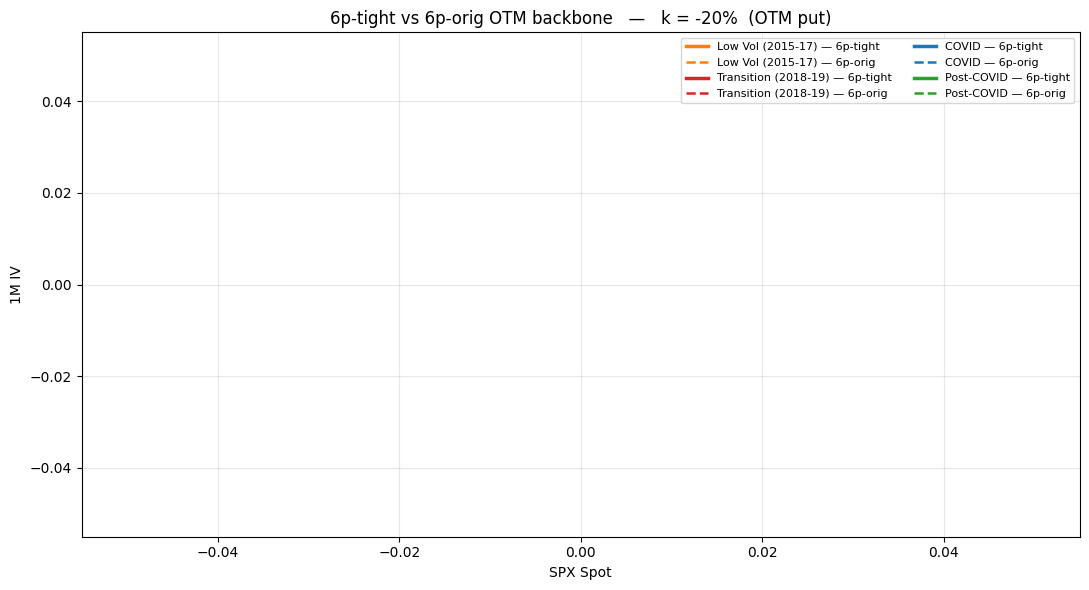

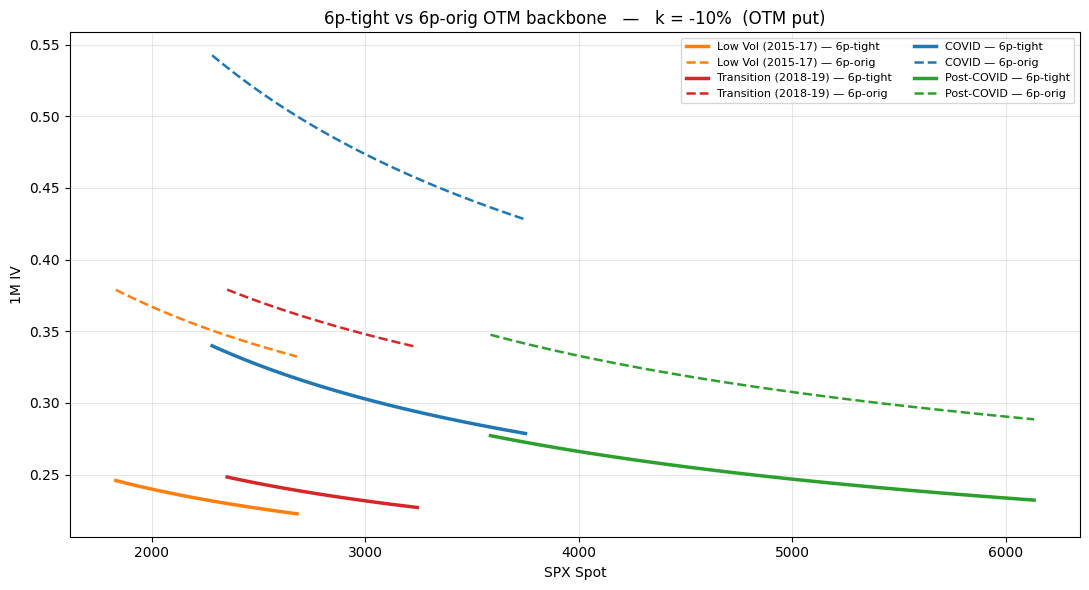

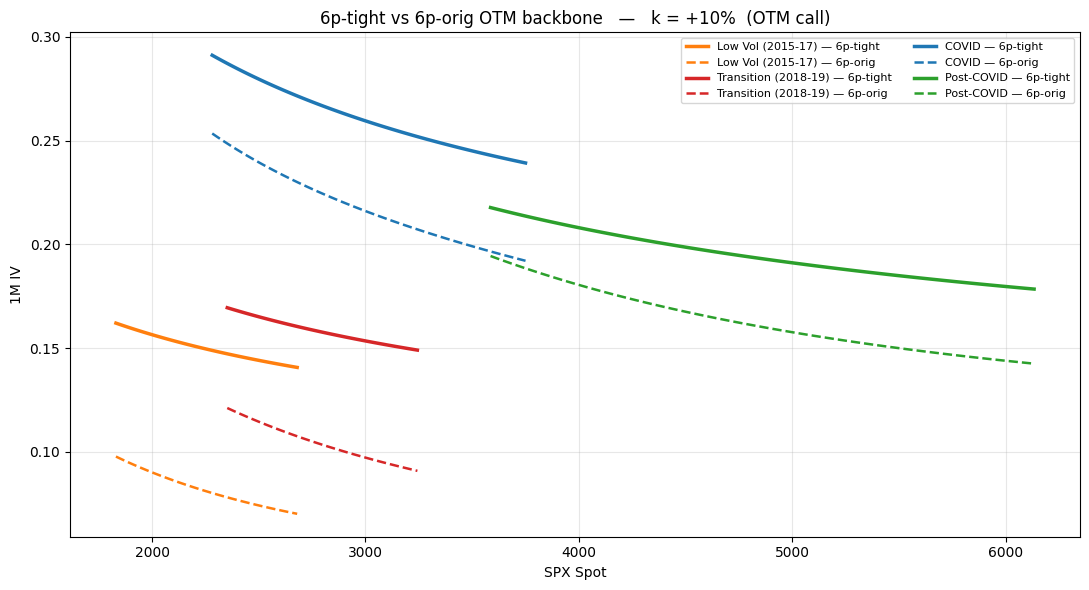

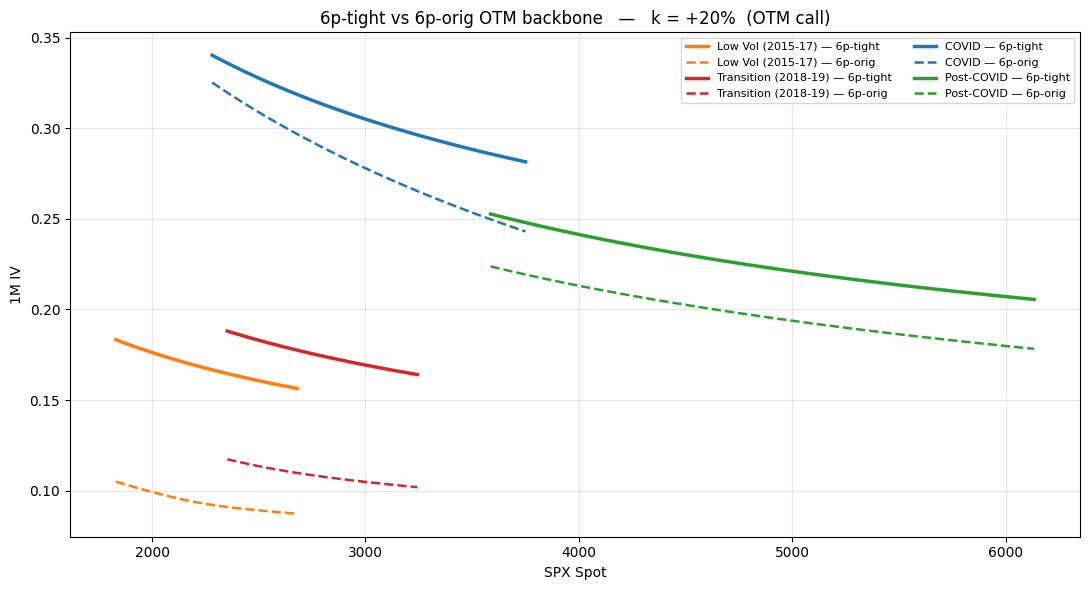

In [9]:
for k_val in K_PLOT_CROSS:
    fig, ax = plt.subplots(figsize=(11, 6))

    for reg in REGIMES:
        # 6p-tight
        f6t = fits_6p_tight[reg]
        w6t, b6t, sl6t = f6t['weights'], f6t['betas'], f6t['sigma_ln_pinned']
        S_ref = f6t['S_ref']; sn6t = sl6t * S_ref

        # 6p-original
        f6o = fits_6p[reg]
        w6o, b6o, sl6o = f6o['weights'], f6o['betas'], f6o['sigma_ln_pinned']
        sn6o = sl6o * S_ref

        g_reg = iv1m_df[iv1m_df['regime'] == reg]
        S_lo = g_reg['spot'].min(); S_hi = g_reg['spot'].max()
        S_grid_reg = np.linspace(S_lo, S_hi, 120)
        K_grid_reg = S_grid_reg * np.exp(k_val)

        backbone_6pt = uncertain_backbone_fast(S_grid_reg, K_grid_reg, R, TARGET_TAU, w6t, b6t, sn6t, sl6t)
        backbone_6po = uncertain_backbone_fast(S_grid_reg, K_grid_reg, R, TARGET_TAU, w6o, b6o, sn6o, sl6o)

        col = regime_colors[reg]
        ax.plot(S_grid_reg, backbone_6pt, color=col, linewidth=2.5,
                label=f'{reg} — 6p-tight')
        ax.plot(S_grid_reg, backbone_6po, color=col, linewidth=1.8,
                linestyle='--', label=f'{reg} — 6p-orig')

    sign = '-' if k_val < 0 else '+'; pct = int(abs(k_val) * 100)
    put_call = 'put' if k_val < 0 else 'call'
    ax.set_title(f'6p-tight vs 6p-orig OTM backbone   —   k = {sign}{pct}%  (OTM {put_call})',
                 fontsize=12)
    ax.set_xlabel('SPX Spot'); ax.set_ylabel('1M IV')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2, loc='upper right')
    plt.tight_layout(); plt.show()


## 10. Summary table

In [10]:
rows = []
for reg in REGIMES:
    sub = direct_otm_df[direct_otm_df['regime'] == reg]
    rmse_6pt = float(np.sqrt(np.mean(sub['residual']**2)))

    # 6p-original OTM RMSE for comparison
    f6o = fits_6p[reg]
    w6o, b6o, sl6o = f6o['weights'], f6o['betas'], f6o['sigma_ln_pinned']
    S_ref = f6o['S_ref']; sn6o = sl6o * S_ref
    resid_6po = []
    for k in K_VALS:
        K = S_ref * np.exp(k)
        m_iv = uncertain_backbone_fast(np.array([S_ref]), np.array([K]), R, TARGET_TAU,
                                      w6o, b6o, sn6o, sl6o)[0]
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset) and not np.isnan(m_iv):
            resid_6po.append(m_iv - subset['iv_1m'].mean())
    rmse_6po = float(np.sqrt(np.mean(np.square(resid_6po)))) if resid_6po else np.nan

    # 9p additive-shift |delta_k| mean
    deltas = []
    g_reg = iv1m_df[iv1m_df['regime'] == reg]
    p9 = fits_9p[reg]['params']
    w9 = np.exp(p9[:3]) / np.sum(np.exp(p9[:3]))
    b9 = p9[3:6]; sl9 = np.abs(p9[6:9]); sn9 = sl9 * S_ref
    S_grid = np.linspace(g_reg['spot'].min(), g_reg['spot'].max(), 150)
    atm_9p = uncertain_backbone_fast(S_grid, S_grid, R, TARGET_TAU, w9, b9, sn9, sl9)
    atm_9p_mean = float(np.nanmean(atm_9p))
    for k in K_VALS:
        if k == 0.0: continue
        subset = iv1m_k_pc_df[(iv1m_k_pc_df['k'] == k) & (iv1m_k_pc_df['regime'] == reg)]
        if len(subset):
            deltas.append(abs(float(subset['iv_1m'].mean()) - atm_9p_mean))
    mean_abs_delta = float(np.mean(deltas)) if deltas else np.nan

    rows.append({
        'regime': reg,
        'ATM_MSE_6p_tight': round(fits_6p_tight[reg]['fun'], 6),
        'ATM_MSE_6p_orig':  round(fits_6p[reg]['fun'], 6),
        'ATM_MSE_9p':       round(fits_9p[reg]['fun'], 6),
        'OTM_RMSE_6p_tight': round(rmse_6pt, 4),
        'OTM_RMSE_6p_orig':  round(rmse_6po, 4),
        'OTM_mean_|delta_k|_9p': round(mean_abs_delta, 4),
        'betas_6p_tight': tuple(np.round(fits_6p_tight[reg]['betas'], 4)),
        'weights_6p_tight': tuple(np.round(fits_6p_tight[reg]['weights'], 4)),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


              regime  ATM_MSE_6p_tight  ATM_MSE_6p_orig  ATM_MSE_9p  OTM_RMSE_6p_tight  OTM_RMSE_6p_orig  OTM_mean_|delta_k|_9p  betas_6p_tight         weights_6p_tight
   Low Vol (2015-17)          0.000932         0.000787    0.000795             0.0385            0.0683                 0.0794 (0.5, 0.5, 0.5)  (0.512, 0.2654, 0.2226)
Transition (2018-19)          0.000978         0.000905    0.000907             0.0144            0.0731                 0.0797 (0.5, 0.5, 0.5)  (0.499, 0.2472, 0.2538)
               COVID          0.006272         0.005626    0.005632             0.0603            0.0512                 0.0983 (0.5, 0.5, 0.5) (0.3966, 0.3461, 0.2572)
          Post-COVID          0.002504         0.002463    0.002463             0.0297            0.0321                 0.0799 (0.5, 0.5, 0.5) (0.5094, 0.2627, 0.2279)


## 11. Interpretation

Reading the summary table and plots:

1. **ATM fit quality**: does tightening β to ≥ 0.5 degrade the ATM MSE
   vs the original 6p?  If the MSE increase is small, the tighter bounds
   haven't cost much ATM accuracy.  If it's large, β < 0.5 was load-bearing.

2. **β values**: are they still at the **new** lower bound (0.5)?  If so,
   the optimiser still wants as much displacement as the bounds allow —
   the displacement mechanism is structurally important for ATM fit.
   If they settle in the interior (e.g. 0.6–0.8), the tight bounds gave
   the optimiser enough room.

3. **OTM direct RMSE**: the key metric.  Compare `OTM_RMSE_6p_tight` vs
   `OTM_RMSE_6p_orig` vs `OTM_mean_|delta_k|_9p`.  If tightening β
   brings the direct OTM RMSE below the 9p additive-shift magnitude,
   the additive shift can be retired.

4. **Cross-regime plots**: do the 6p-tight backbones (solid) now track
   the observed OTM scatter more closely than 6p-orig (dashed)?  Look for
   the put-wing (k = -0.2, -0.1) in particular — the original 6p
   over-estimated these by 50–90%; the tight version should be much
   closer to the observed means.
